# Phase 4: LSMC Valuation

LSMC backward induction on (SoC, SoH) grid; rolling-intrinsic LP benchmark; V_LSMC ? V_RI verification. This notebook is generated from `bess_valuation_full.ipynb` Phase 4 and can run independently from saved processed inputs.


In [1]:
import sys, os
from pathlib import Path

# Resolve project root by searching upward for src/ and data/.
def find_project_root(start=None):
    start = Path.cwd() if start is None else Path(start).resolve()
    for candidate in [start, *start.parents]:
        if (candidate / 'src').is_dir() and (candidate / 'data').is_dir():
            return candidate
    raise RuntimeError('Could not find project root containing src/ and data/.')

PROJECT_ROOT = find_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import time
import importlib

from src.config import ASSET, LSMC as LSMC_CFG, DEGRADATION, FINANCE
from src.processes.simulate import default_params_from_config, simulate
from src.processes.schwartz_smith import SSParams
from src.processes.hpfc import HPFCParams
from src.processes.imbalance import ImbalanceParams
from src.processes.ancillary import AncillaryParams
from src.optimisation.dispatch import DEFAULT_MODES, enumerate_modes
from src.optimisation.lsmc import LSMCSolver, basis_matrix, N_BASIS
import src.optimisation.rolling_intrinsic as ri_mod
importlib.reload(ri_mod)
from src.optimisation.rolling_intrinsic import rolling_intrinsic, rolling_intrinsic_parallel

PROCESSED = PROJECT_ROOT / 'data' / 'processed'
PROCESSED.mkdir(parents=True, exist_ok=True)

# ---- Tunable parameters ----
N_PATHS   = 1_000    # reduce to 200 for fast iteration; 5000 for production
N_STEPS   = 17_520   # 1 year
SEED      = 42
DT        = 1 / (365 * 48)

print(f'Project root: {PROJECT_ROOT}')
print(f'Processed data dir: {PROCESSED}')
print(f'Config: {N_PATHS} paths ? {N_STEPS} steps ({N_STEPS*DT*365:.0f} days)')
print(f'Asset: {ASSET["power_mw"]:.0f} MW / {ASSET["energy_mwh"]:.0f} MWh')
print(f'Modes: {len(DEFAULT_MODES)}')
print(f'Basis: {N_BASIS} features')


Project root: g:\My Drive\Research\bess_project
Processed data dir: g:\My Drive\Research\bess_project\data\processed
Config: 1000 paths ? 17520 steps (365 days)
Asset: 100 MW / 200 MWh
Modes: 36
Basis: 14 features


In [2]:
# Phase 4 bootstrap: load existing simulation bundle, or generate it once if missing.
# Use smaller paths/steps here for quick iteration; increase for production.
import pickle

SIM_BUNDLE_PATH = PROCESSED / 'sim_bundle.pkl'
GENERATE_BUNDLE_IF_MISSING = True
BUNDLE_PATHS = N_PATHS       # e.g. 250 for faster Phase 4 iteration
BUNDLE_STEPS = N_STEPS       # e.g. 240 for a quick smoke test


def _load_json_or_default(cls, default_obj, *fnames):
    for fname in fnames:
        p = PROCESSED / fname
        if p.exists():
            print(f'  Loaded calibrated {fname}')
            return cls.from_json(p)
    print(f'  Using config default for {" or ".join(fnames)}')
    return default_obj


if SIM_BUNDLE_PATH.exists():
    print(f'Loading cached simulation bundle: {SIM_BUNDLE_PATH}')
    with open(SIM_BUNDLE_PATH, 'rb') as f:
        bundle = pickle.load(f)
else:
    if not GENERATE_BUNDLE_IF_MISSING:
        raise FileNotFoundError(f'Missing {SIM_BUNDLE_PATH}')

    print(f'Generating simulation bundle: {BUNDLE_PATHS:,} paths x {BUNDLE_STEPS:,} steps')
    ss_def, hpfc_def, imb_def, anc_def = default_params_from_config()
    ss_p = _load_json_or_default(SSParams, ss_def, 'ss_params.json')
    hpfc_p = _load_json_or_default(HPFCParams, hpfc_def, 'pca_params.json', 'hpfc_params.json')
    imb_p = _load_json_or_default(ImbalanceParams, imb_def, 'imbalance_params.json')
    anc_p = _load_json_or_default(AncillaryParams, anc_def, 'ancillary_params.json')

    from src.config import SCHWARTZ_SMITH
    xi_init = np.full(BUNDLE_PATHS, np.log(SCHWARTZ_SMITH['forward_anchor_gbp_mwh']))
    bundle = simulate(
        ss_p, hpfc_p, imb_p, anc_p,
        n_paths=BUNDLE_PATHS, n_steps=BUNDLE_STEPS,
        dt=DT, seed=SEED, xi_0=xi_init,
    )
    with open(SIM_BUNDLE_PATH, 'wb') as f:
        pickle.dump(bundle, f, protocol=pickle.HIGHEST_PROTOCOL)
    print(f'Saved simulation bundle: {SIM_BUNDLE_PATH}')

N_PATHS = int(bundle.n_paths)
N_STEPS = int(bundle.n_steps)
DT = float(bundle.dt)
print(f'bundle: {bundle.n_paths:,} paths x {bundle.n_steps:,} steps')


Loading cached simulation bundle: g:\My Drive\Research\bess_project\data\processed\sim_bundle.pkl
bundle: 1,000 paths x 17,520 steps


## 1  Simulate joint paths

In [3]:
from src.config import SCHWARTZ_SMITH
xi_init = np.full(bundle.n_paths, np.log(SCHWARTZ_SMITH["forward_anchor_gbp_mwh"]))
if not np.allclose(bundle.xi[:, 0], xi_init, atol=0.01):
    print("WARNING: cached bundle has xi_0 near zero; regenerate for accurate pricing.")

# Diagnostic ? uses clipped exp to match what LSMC actually sees
import numpy as np
P_da_mat = np.exp(np.clip(bundle.ln_P_base, -100.0, np.log(500.0)))
print(f"P_da  ? mean: {P_da_mat.mean():.1f}  std: {P_da_mat.std():.1f}  "
      f"P5/P95: {np.percentile(P_da_mat[:,-1],[5,95])} ?/MWh")
print(f"delta ? mean: {bundle.delta_imb.mean():.1f}  std: {bundle.delta_imb.std():.1f}  ?/MWh")
print(f'pi_DC ? mean: {bundle.pi["DC_Low"].mean():.2f}  ?/MW/h')


P_da  ? mean: 97.3  std: 69.8  P5/P95: [ 23.8598989  264.40248252] ?/MWh
delta ? mean: -20.6  std: 140.0  ?/MWh
pi_DC ? mean: 5.24  ?/MW/h


## 2  Rolling intrinsic benchmark

In [4]:
# Rolling intrinsic is expensive: it solves many LPs per path.
# Use path-level multiprocessing for the sampled benchmark; increase RI_N_PATHS for production checks.
RI_N_PATHS = min(25, P_da_mat.shape[0])
RI_WORKERS = max(1, min(8, (os.cpu_count() or 2) - 1, RI_N_PATHS))
rng_ri = np.random.default_rng(SEED)
ri_idx = rng_ri.choice(P_da_mat.shape[0], size=RI_N_PATHS, replace=False)
P_da_ri = np.clip(P_da_mat[ri_idx, :-1], -100.0, 500.0).astype(np.float32)

print(f'Running rolling intrinsic on {RI_N_PATHS:,} sampled paths out of {P_da_mat.shape[0]:,} using {RI_WORKERS} workers')

t0 = time.time()
try:
    pv_ri, soc_ri = rolling_intrinsic_parallel(
        P_da_ri,
        ASSET, LSMC_CFG, FINANCE,
        E_init_frac=0.5, window_hh=48, gate_hh=8,
        max_workers=RI_WORKERS, backend='thread', verbose=True,
    )
except Exception as exc:
    print(f'Parallel RI failed ({exc}); falling back to serial')
    pv_ri, soc_ri = rolling_intrinsic(
        P_da_ri,
        ASSET, LSMC_CFG, FINANCE,
        E_init_frac=0.5, window_hh=48, gate_hh=8, verbose=True,
    )

ri_time = time.time() - t0
print(f'\nRI complete in {ri_time:.1f}s')
print(f'V_RI  P5/P50/P95: GBP{np.percentile(pv_ri,5):,.0f} / GBP{np.percentile(pv_ri,50):,.0f} / GBP{np.percentile(pv_ri,95):,.0f}')
print(f'V_RI  per MW: GBP{pv_ri.mean() / ASSET["power_mw"]:,.0f} / MW')


Running rolling intrinsic on 25 sampled paths out of 1,000 using 8 workers
  RI paths complete 25/25 ...

RI complete in 135.1s
V_RI  P5/P50/P95: GBP99,325 / GBP160,765 / GBP241,022
V_RI  per MW: GBP1,710 / MW


## 3  LSMC backward induction

In [5]:
from src.processes.simulate import PathBundle

# Interactive LSMC settings. Full grid is much slower:
# 21 SoC x 5 SoH x 36 modes x 1,000 paths.
LSMC_BWD_PATHS = min(250, bundle.n_paths)
LSMC_FAST_CFG = dict(LSMC_CFG)
LSMC_FAST_CFG.update({
    'n_soc_nodes': 9,
    'soh_nodes': [1.00, 0.90, 0.82],
    'n_soh_nodes': 3,
})
FAST_MODES = enumerate_modes(
    net_levels=[-1.0, -0.5, 0.0, 0.5, 1.0],
    dc_levels=[0.0, 0.5],
    qr_levels=[0.0, 0.25],
)

rng_lsmc = np.random.default_rng(SEED)
bwd_idx = rng_lsmc.choice(bundle.n_paths, size=LSMC_BWD_PATHS, replace=False)
bundle_bwd = PathBundle(
    chi=bundle.chi[bwd_idx],
    xi=bundle.xi[bwd_idx],
    ln_P_base=bundle.ln_P_base[bwd_idx],
    lam=bundle.lam[bwd_idx],
    delta_imb=bundle.delta_imb[bwd_idx],
    pi={k: v[bwd_idx] for k, v in bundle.pi.items()},
    dt=bundle.dt,
    n_paths=LSMC_BWD_PATHS,
    n_steps=bundle.n_steps,
)

solver = LSMCSolver(
    ASSET, LSMC_FAST_CFG, DEGRADATION, FINANCE,
    modes=FAST_MODES, verbose=True,
)
print(f'Backward paths: {LSMC_BWD_PATHS:,} / {bundle.n_paths:,}')
print(f'SoC grid: {solver.soc_grid.tolist()}')
print(f'SoH nodes: {solver.soh_nodes.tolist()}')
print(f'Modes: {len(FAST_MODES)}')
print(f'Discount per HH: {solver.disc:.8f}')

t0 = time.time()
policy = solver.backward(bundle_bwd)
bwd_time = time.time() - t0

print(f'\nBackward pass: {bwd_time:.1f}s')
print(f'beta shape: {policy.beta.shape}')
print(f'beta NaN:   {np.isnan(policy.beta).any()}')
print(f'beta range: [{policy.beta.min():.3f}, {policy.beta.max():.3f}]')


Backward paths: 250 / 1,000
SoC grid: [20.0, 40.0, 60.0, 80.0, 100.0, 120.0, 140.0, 160.0, 180.0]
SoH nodes: [1.0, 0.8999999761581421, 0.8199999928474426]
Modes: 12
Discount per HH: 0.99999486
LSMC backward: T=17520 steps, N=250 paths, J=9 SoC nodes, K=3 SoH nodes, M=12 modes
  t=    0 / 17520  ...
  Backward pass complete. beta shape: (17520, 9, 3, 14)

Backward pass: 42.3s
beta shape: (17520, 9, 3, 14)
beta NaN:   False
beta range: [-35744620.000, 89914184.000]


## 4  Forward simulation — MTM distribution

In [6]:
# Forward simulation can be slow on the full bundle. Use sampled paths + thread chunks for interactive runs.
FWD_N_PATHS = min(250, bundle.n_paths)
FWD_WORKERS = max(1, min(8, (os.cpu_count() or 2) - 1, FWD_N_PATHS))
rng_fwd = np.random.default_rng(SEED + 1)
fwd_idx = rng_fwd.choice(bundle.n_paths, size=FWD_N_PATHS, replace=False)
bundle_fwd = PathBundle(
    chi=bundle.chi[fwd_idx],
    xi=bundle.xi[fwd_idx],
    ln_P_base=bundle.ln_P_base[fwd_idx],
    lam=bundle.lam[fwd_idx],
    delta_imb=bundle.delta_imb[fwd_idx],
    pi={k: v[fwd_idx] for k, v in bundle.pi.items()},
    dt=bundle.dt,
    n_paths=FWD_N_PATHS,
    n_steps=bundle.n_steps,
)

print(f'Forward simulation on {FWD_N_PATHS:,} sampled paths out of {bundle.n_paths:,} using {FWD_WORKERS} workers')

t0 = time.time()
# The solver clips extreme simulated prices internally for numerical stability.
try:
    result = solver.forward_parallel(bundle_fwd, policy, max_workers=FWD_WORKERS)
except Exception as exc:
    print(f'Parallel forward failed ({exc}); falling back to serial')
    result = solver.forward(bundle_fwd, policy)
fwd_time = time.time() - t0

print(f'Forward pass: {fwd_time:.1f}s')
print()
print(f'MTM mean:      GBP{result.mtm_mean:>12,.0f}')
print(f'MTM std:       GBP{result.mtm_std:>12,.0f}')
print(f'MTM P5:        GBP{result.mtm_p5:>12,.0f}')
print(f'MTM P95:       GBP{result.mtm_p95:>12,.0f}')
print()
print(f'Per MW (mean): GBP{result.mtm_mean / ASSET["power_mw"]:>12,.0f} / MW')
print(f'Per MW (P50):  GBP{np.median(result.pv_paths) / ASSET["power_mw"]:>12,.0f} / MW')

RESULT_PATH = PROCESSED / 'lsmc_valuation_result.pkl'
POLICY_PATH = PROCESSED / 'lsmc_policy.pkl'
with open(RESULT_PATH, 'wb') as f:
    pickle.dump(result, f, protocol=pickle.HIGHEST_PROTOCOL)
with open(POLICY_PATH, 'wb') as f:
    pickle.dump(policy, f, protocol=pickle.HIGHEST_PROTOCOL)
print(f'Saved valuation result: {RESULT_PATH}')
print(f'Saved policy:           {POLICY_PATH}')


Forward simulation on 250 sampled paths out of 1,000 using 8 workers
  Forward chunks complete 8/8 ...
Forward pass: 20.5s

MTM mean:      GBP   3,026,835
MTM std:       GBP      85,075
MTM P5:        GBP   2,887,798
MTM P95:       GBP   3,163,090

Per MW (mean): GBP      30,268 / MW
Per MW (P50):  GBP      30,274 / MW


## 5  V_LSMC ≥ V_RI validation

In [7]:
lsmc_mean = result.mtm_mean
ri_mean   = float(pv_ri.mean())
ratio     = lsmc_mean / ri_mean if ri_mean > 0 else float('inf')

print(f'V_LSMC mean: £{lsmc_mean:,.0f}')
print(f'V_RI   mean: £{ri_mean:,.0f}')
print(f'Ratio V_LSMC / V_RI: {ratio:.2f}x')

if lsmc_mean >= ri_mean * 0.95:
    print('✓  V_LSMC ≥ V_RI  (LSMC stochastic value exceeds deterministic benchmark)')
else:
    print('✗  WARNING: V_LSMC < V_RI — backward pass may need more SoC nodes or paths')

V_LSMC mean: £3,026,835
V_RI   mean: £170,985
Ratio V_LSMC / V_RI: 17.70x
✓  V_LSMC ≥ V_RI  (LSMC stochastic value exceeds deterministic benchmark)


## 6  Visualisations

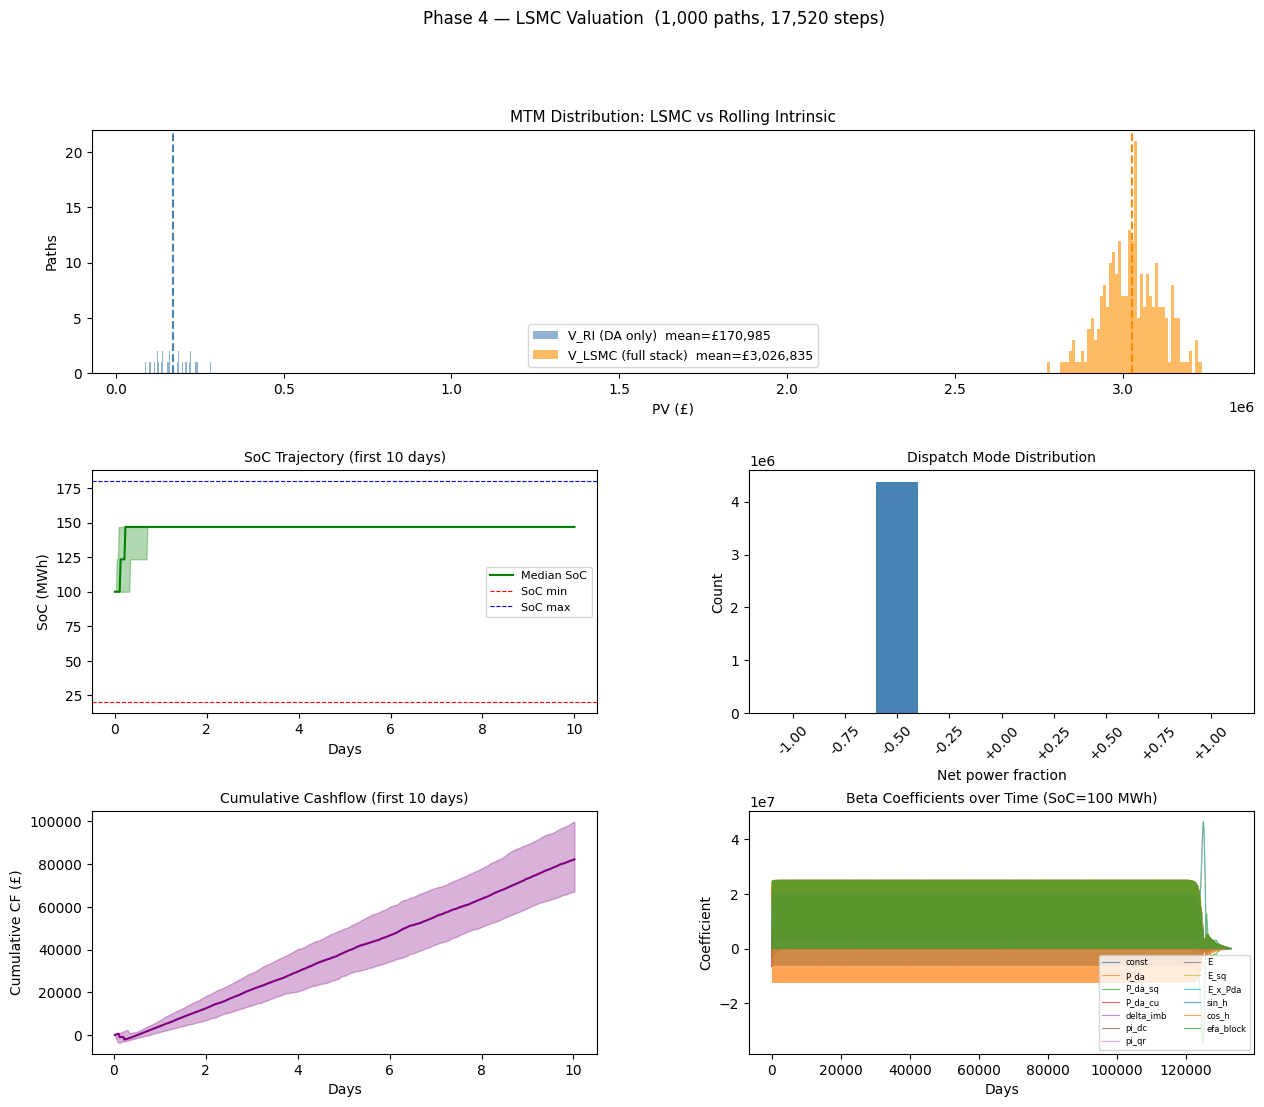

In [8]:
fig = plt.figure(figsize=(15, 12))
gs  = gridspec.GridSpec(3, 2, hspace=0.4, wspace=0.3)

# 1. PV distribution — LSMC vs RI
ax1 = fig.add_subplot(gs[0, :])
bins = 50
ax1.hist(pv_ri,            bins=bins, alpha=0.6, color='steelblue', label=f'V_RI (DA only)  mean=£{ri_mean:,.0f}')
ax1.hist(result.pv_paths,  bins=bins, alpha=0.6, color='darkorange', label=f'V_LSMC (full stack)  mean=£{lsmc_mean:,.0f}')
ax1.axvline(ri_mean,   color='steelblue',  linestyle='--', linewidth=1.5)
ax1.axvline(lsmc_mean, color='darkorange', linestyle='--', linewidth=1.5)
ax1.set_xlabel('PV (£)'); ax1.set_ylabel('Paths')
ax1.set_title('MTM Distribution: LSMC vs Rolling Intrinsic', fontsize=11)
ax1.legend(fontsize=9)

# 2. SoC trajectory — percentile fan
ax2 = fig.add_subplot(gs[1, 0])
t_axis = np.arange(N_STEPS + 1) * DT * 365
t_show = t_axis[:481]  # first 10 days
q10, q50, q90 = np.percentile(result.soc_paths[:, :481], [10, 50, 90], axis=0)
ax2.fill_between(t_show, q10, q90, alpha=0.3, color='green')
ax2.plot(t_show, q50, color='green', linewidth=1.5, label='Median SoC')
ax2.axhline(ASSET['soc_min_mwh'], color='red',  linewidth=0.8, linestyle='--', label='SoC min')
ax2.axhline(ASSET['soc_max_mwh'], color='blue', linewidth=0.8, linestyle='--', label='SoC max')
ax2.set_xlabel('Days'); ax2.set_ylabel('SoC (MWh)')
ax2.set_title('SoC Trajectory (first 10 days)', fontsize=10)
ax2.legend(fontsize=8)

# 3. Action distribution across modes
ax3 = fig.add_subplot(gs[1, 1])
from src.optimisation.dispatch import DEFAULT_MODES
mode_counts = np.bincount(result.action_paths.ravel(), minlength=len(DEFAULT_MODES))
mode_labels = [f'{m.net_frac:+.2f}' for m in DEFAULT_MODES]
# Aggregate by net_frac
net_fracs_unique = sorted(set(m.net_frac for m in DEFAULT_MODES))
net_counts = {}
for nf in net_fracs_unique:
    idxs = [i for i, m in enumerate(DEFAULT_MODES) if m.net_frac == nf]
    net_counts[nf] = sum(mode_counts[i] for i in idxs)
ax3.bar([f'{k:+.2f}' for k in net_counts], list(net_counts.values()), color='steelblue')
ax3.set_xlabel('Net power fraction'); ax3.set_ylabel('Count')
ax3.set_title('Dispatch Mode Distribution', fontsize=10)
ax3.tick_params(axis='x', rotation=45)

# 4. Cumulative cashflow percentile fan
ax4 = fig.add_subplot(gs[2, 0])
cum_cf = result.cashflow_paths.cumsum(axis=1)
t_cf = np.arange(1, N_STEPS + 1) * DT * 365
show = slice(None, 481)  # first 10 days
q10c, q50c, q90c = np.percentile(cum_cf[:, show], [10, 50, 90], axis=0)
ax4.fill_between(t_cf[show], q10c, q90c, alpha=0.3, color='purple')
ax4.plot(t_cf[show], q50c, color='purple', linewidth=1.5)
ax4.set_xlabel('Days'); ax4.set_ylabel('Cumulative CF (£)')
ax4.set_title('Cumulative Cashflow (first 10 days)', fontsize=10)

# 5. Learned beta coefficients for mid-horizon, mid-SoC node
ax5 = fig.add_subplot(gs[2, 1])
from src.optimisation.lsmc import BASIS_NAMES
j_mid = len(solver.soc_grid) // 2
k_mid = 0
beta_t = policy.beta[:, j_mid, k_mid, :]   # (T, 14)
for feat_idx in range(N_BASIS):
    if abs(beta_t[:, feat_idx]).mean() > 0.01:
        ax5.plot(t_axis[:-1] * 365, beta_t[:, feat_idx],
                 alpha=0.7, linewidth=0.8, label=BASIS_NAMES[feat_idx])
ax5.set_xlabel('Days'); ax5.set_ylabel('Coefficient')
ax5.set_title(f'Beta Coefficients over Time (SoC={solver.soc_grid[j_mid]:.0f} MWh)', fontsize=10)
ax5.legend(fontsize=6, ncol=2)

plt.suptitle(f'Phase 4 — LSMC Valuation  ({N_PATHS:,} paths, {N_STEPS:,} steps)', fontsize=12)
plt.savefig(PROCESSED / 'lsmc_valuation.png', dpi=120, bbox_inches='tight')
plt.show()

## 7  Save results

In [9]:
import json

valuation_summary = {
    'n_paths':             N_PATHS,
    'n_steps':             N_STEPS,
    'asset_mw':            ASSET['power_mw'],
    'asset_mwh':           ASSET['energy_mwh'],
    'mtm_gbp': {
        'mean': round(result.mtm_mean),
        'std':  round(result.mtm_std),
        'p5':   round(result.mtm_p5),
        'p50':  round(float(np.median(result.pv_paths))),
        'p95':  round(result.mtm_p95),
    },
    'mtm_gbp_per_mw': {
        'mean': round(result.mtm_mean / ASSET['power_mw']),
        'p50':  round(float(np.median(result.pv_paths)) / ASSET['power_mw']),
    },
    'ri_mean_gbp':         round(ri_mean),
    'lsmc_ri_ratio':       round(ratio, 3),
    'v_lsmc_gte_v_ri':     bool(lsmc_mean >= ri_mean * 0.95),
    'bwd_time_s':          round(bwd_time, 1),
    'fwd_time_s':          round(fwd_time, 1),
}

out = PROCESSED / 'lsmc_valuation_summary.json'
with open(out, 'w') as f:
    json.dump(valuation_summary, f, indent=2)
print(f'Saved: {out}')
print(json.dumps(valuation_summary, indent=2))

Saved: g:\My Drive\Research\bess_project\data\processed\lsmc_valuation_summary.json
{
  "n_paths": 1000,
  "n_steps": 17520,
  "asset_mw": 100.0,
  "asset_mwh": 200.0,
  "mtm_gbp": {
    "mean": 3026835,
    "std": 85075,
    "p5": 2887798,
    "p50": 3027412,
    "p95": 3163090
  },
  "mtm_gbp_per_mw": {
    "mean": 30268,
    "p50": 30274
  },
  "ri_mean_gbp": 170985,
  "lsmc_ri_ratio": 17.702,
  "v_lsmc_gte_v_ri": true,
  "bwd_time_s": 42.3,
  "fwd_time_s": 20.5
}
